# Problema 3 - Algoritmos de Aproximación
Preparamos el entorno e importamos las librearias necesarias

In [5]:
%pip install -q matplotlib seaborn scipy

You should consider upgrading via the '/Users/nchen/Desktop/tda tp2/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
import sys
import random
import numpy as np
import scipy as sp
import seaborn as sns
from matplotlib import pyplot as plt

# Importamos módulos desde el directorio actual y su padre
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(current_dir)
sys.path.append(parent_dir)

# Importamos la función a probar
from problema_3 import subconjunto_factible_aprox
from util import time_algorithm

# Establecemos semillas para la reproducibilidad de los resultados
random.seed(12345)
np.random.seed(12345)
sns.set_theme(style="whitegrid")

## Generación de datos para las mediciones y gráficos
Para cada tamaño $n$, generamos un arreglo de valores enteros aleatorios entre 1 y 5.000, y una cota $B$ que es aproximadamente el 40% de la suma total de los valores. Los tamaños de entrada varían linealmente desde 1.000 hasta 100.000 elementos, distribuidos uniformemente en 20 puntos de medición.

Luego medimos el tiempo promedio de resolución usando `time_algorithm`.

Finalmente, graficamos los resultados obtenidos para el tiempo de ejecución y la calidad de la aproximación, comparándolos con las referencias teóricas correspondientes a $O(nlogn)$.


In [14]:
def generar_instancia(n: int, limite_valor: int = 5_000, proporcion_b: float = 0.4):
    valores = np.random.randint(1, limite_valor + 1, size=n).tolist()
    cota = max(1, int(sum(valores) * proporcion_b))
    return valores, cota

x = np.linspace(1_000, 100_000, 20, dtype=int)
print(x)

results_tiempo_s = time_algorithm(subconjunto_factible_aprox, x, generar_instancia)
results_tiempo = {int(n): t * 1000.0 for n, t in results_tiempo_s.items()}

print("Resultados (ms):")
for n, t in results_tiempo.items():
    print(f"Tiempo para n={n}: {t:.12g} ms")

[  1000   6210  11421  16631  21842  27052  32263  37473  42684  47894
  53105  58315  63526  68736  73947  79157  84368  89578  94789 100000]
Resultados (ms):
Tiempo para n=1000: 0.240230560303 ms
Tiempo para n=6210: 1.84440612793 ms
Tiempo para n=11421: 3.7223815918 ms
Tiempo para n=16631: 5.52771091461 ms
Tiempo para n=21842: 7.93280601501 ms
Tiempo para n=27052: 6.69050216675 ms
Tiempo para n=32263: 7.52038955688 ms
Tiempo para n=37473: 8.69860649109 ms
Tiempo para n=42684: 10.5468273163 ms
Tiempo para n=47894: 12.6187086105 ms
Tiempo para n=53105: 15.0874376297 ms
Tiempo para n=58315: 15.0404453278 ms
Tiempo para n=63526: 15.5441999435 ms
Tiempo para n=68736: 17.2255039215 ms
Tiempo para n=73947: 22.1728801727 ms
Tiempo para n=79157: 21.3397264481 ms
Tiempo para n=84368: 21.0111856461 ms
Tiempo para n=89578: 24.335193634 ms
Tiempo para n=94789: 25.1431703568 ms
Tiempo para n=100000: 26.5500545502 ms


c_1 = 2.23796277232e-05, c_2 = 0.964929179572
Error cuadrático total (tiempo): 21.8687558942


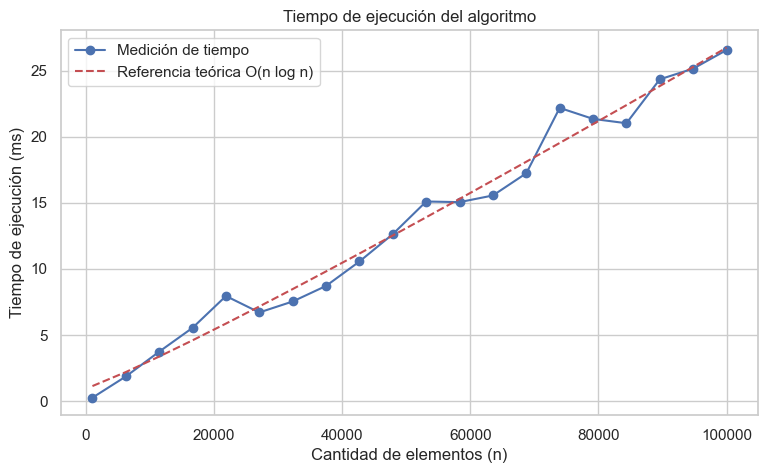

In [15]:
# scipy nos pide una función que recibe primero x y luego los parámetros a ajustar:
f_tiempo = lambda x, c1, c2:c1 * x * np.log(x) + c2
c_t, _ = sp.optimize.curve_fit(f_tiempo, x, [results_tiempo[n] for n in x])
r_t = np.sum((c_t[0] * x * np.log(x) + c_t[1] - [results_tiempo[n] for n in x])**2)

print(f"c_1 = {c_t[0]:.12g}, c_2 = {c_t[1]:.12g}")
print(f"Error cuadrático total (tiempo): {r_t:.12g}")

ax: plt.Axes
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, [results_tiempo[n] for n in x], "o-", label="Medición de tiempo")
ax.plot(x, [c_t[0] * n * np.log(n) + c_t[1] for n in x], "r--", label="Referencia teórica O(n log n)")
ax.set_title("Tiempo de ejecución del algoritmo")
ax.set_xlabel("Cantidad de elementos (n)")
ax.set_ylabel("Tiempo de ejecución (ms)")
ax.legend()

Text(0, 0.5, 'Error absoluto (ms)')

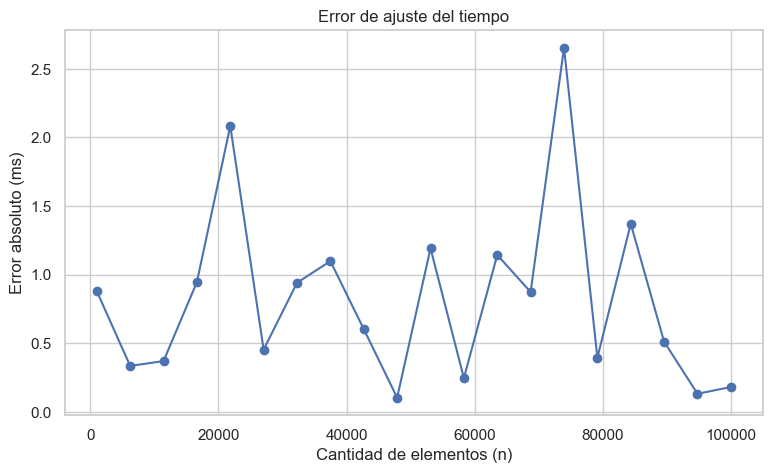

In [16]:
ax: plt.Axes
fig, ax = plt.subplots(figsize=(9, 5))
errors_tiempo = [np.abs(c_t[0] * n * np.log(n) + c_t[1] - results_tiempo[n]) for n in x]
ax.plot(x, errors_tiempo, "o-")
ax.set_title("Error de ajuste del tiempo")
ax.set_xlabel("Cantidad de elementos (n)")
ax.set_ylabel("Error absoluto (ms)")